# Module 7- Plotting and Visualization

1. This exercise uses the same fake ABA session data as in the previous exercises, except it is clean. 
1. The code below generates fake ABA session data with 10,000 samples. 
1. The data is fake, but the concepts and operations we will cover in this module are directly applicable to your work with real data. 
1. If you ever need to make a new dataframe with the fake data, please use this in any cell: `df = pd.DataFrame(data)`

In [11]:
import pandas as pd
import numpy as np
import random
import uuid

# Set the seed for reproducibility
np.random.seed(101214)

# Generate fake ABA session data
num_samples = 10_000
clients = ["Bob", "Rohan", "Milo", "Moana", "Maddie"]

data = {
    "session_id": [uuid.uuid4() for _ in range(num_samples)],
    "date": pd.date_range(start="2025-01-01", periods=num_samples, freq="h").strftime("%Y-%m-%d %H:%M"),
    "client_name": [str(np.random.choice(clients)) for _ in range(num_samples)],
    "therapist": [str(np.random.choice(["Emmet", "Blaze", "Uma", "Lily"])) for _ in range(num_samples)],
    "target_behavior": [str(np.random.choice(["Mand for Item", "Eye Contact", "Functional Play", "Following Directions"])) for _ in range(num_samples)],
    "reinforcement_strategy": [str(np.random.choice(["Token System", "Edible", "Verbal Praise", "Break Time"])) for _ in range(num_samples)],
    "trials": np.where(np.random.rand(num_samples) < 0.05, np.nan, np.random.randint(5, 20, size=num_samples)),
    "prompt_level": [str(np.random.choice(["Full", "Partial", "Independent"])) for _ in range(num_samples)],
    "session_duration": np.random.randint(30, 121, size=num_samples),
    "session_type": [str(np.random.choice(["In-Person", "Telehealth"])) for _ in range(num_samples)],
    "engagement_level": [np.random.choice(["High", "Moderate", "Low"]) for _ in range(num_samples)],
    "challenging_behavior_observed": [str(np.random.choice(["Yes", "No"], p=[0.3, 0.7])) for _ in range(num_samples)],
    "therapist_notes": [
        np.random.choice(["Client was focused", "Needed multiple prompts", "Great session!", "Some difficulty transitioning"])
        for _ in range(num_samples)
    ]
}

df = pd.DataFrame(data)

# Apply correlation-based generation for 'correct_responses' with 50%-100% range
correct_responses = []

for index, row in df.iterrows():
    trials = row['trials']
    client = row['client_name']

    if pd.isna(trials):
        # If trials is NaN, set a random value for correct_responses
        correct_responses.append(np.random.randint(3, 15))
        continue

    # Generate correct responses based on client type with 50%-100% of trials
    if client == "Bob":
        # 0.75 positive correlation
        mean_correct = np.clip(0.75 * trials, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    elif client == "Rohan":
        # 0.3 positive correlation
        mean_correct = np.clip(0.3 * trials, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 2), 0.5 * trials, trials)))
    elif client == "Milo":
        # Asymptotic relationship
        mean_correct = np.clip(15 * (1 - np.exp(-trials / 10)), 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    elif client == "Moana":
        # Inverted U relationship
        mean_correct = np.clip(-0.5 * (trials - 12) ** 2 + 10, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    elif client == "Maddie":
        # -0.5 negative correlation
        mean_correct = np.clip(15 - 0.5 * trials, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    else:
        # Default case if something goes wrong
        correct_responses.append(int(np.clip(np.random.uniform(0.5, 1.0) * trials, 0.5 * trials, trials)))

# Assign the generated 'correct_responses' to the DataFrame
df['correct_responses'] = correct_responses

df.head()

,session_id,date,client_name,therapist,target_behavior,reinforcement_strategy,trials,prompt_level,session_duration,session_type,engagement_level,challenging_behavior_observed,therapist_notes,correct_responses
0,201e1c4e-8e21-445c-827f-eab0eb761d09,2025-01-01 00:00,Maddie,Uma,Following Directions,Token System,7.0,Independent,51,Telehealth,Low,Yes,Client was focused,7
1,f9741f3d-0d57-4466-9963-3a8f0b662afc,2025-01-01 01:00,Maddie,Blaze,Mand for Item,Edible,16.0,Full,86,Telehealth,High,No,Some difficulty transitioning,8
2,ec9d6587-0882-4280-8704-7979cf958afc,2025-01-01 02:00,Maddie,Lily,Functional Play,Token System,19.0,Independent,93,Telehealth,Moderate,Yes,Great session!,9
3,fddff3fa-e003-4552-9e06-27e2494b696a,2025-01-01 03:00,Rohan,Uma,Mand for Item,Token System,12.0,Partial,99,In-Person,Moderate,Yes,Client was focused,6
4,b4bbc9dc-9c6e-477a-999a-ac9d28b4e749,2025-01-01 04:00,Rohan,Emmet,Mand for Item,Edible,9.0,Partial,111,In-Person,High,Yes,Some difficulty transitioning,5


In [12]:
# Q1 Import the necessary librarys (Pandas, Numpy, Seaborn, Matplotlib)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

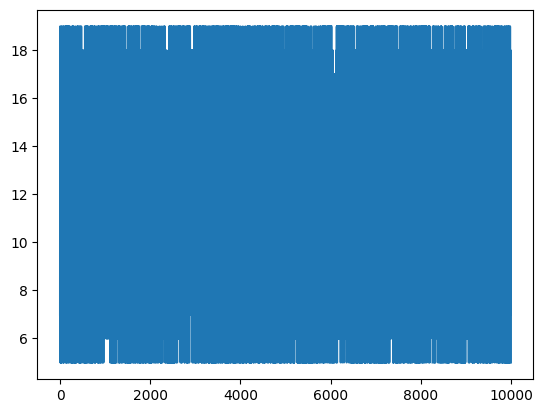

In [13]:
# Q2 Using plt.plot(), create a simple plot pf the trials column 
plt.plot(df['trials'])
plt.show()
# Yikes, that is messy. 

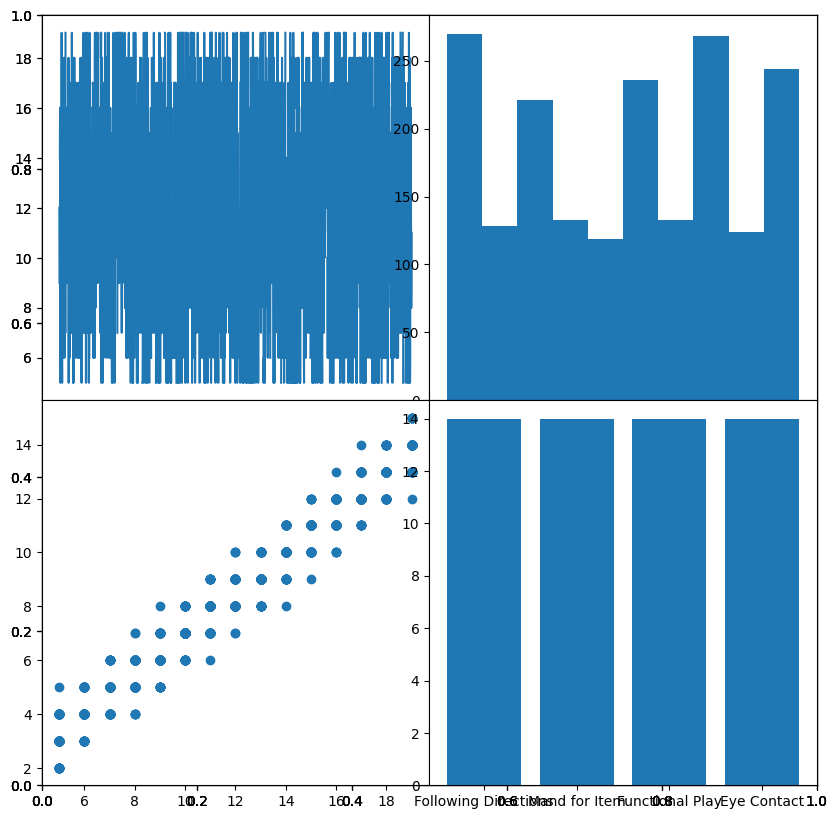

In [14]:
#Q3 Create a new figure object and assign it to fig. The dimensions should be (10, 10)
fig = plt.figure(figsize=(10, 10))
#Q4 Create a new subplot object and assign it to ax1
ax1 = fig.add_subplot(111)
#Q5 Create a new subplot object and assign it to ax2
ax2 = fig.add_subplot(111)
#Q6 Create a new subplot object and assign it to ax3
ax3 = fig.add_subplot(111)
#Q7 Create a new subplot object and assign it to ax4
ax4 = fig.add_subplot(111)
#Q8 Subset the dataframe to only include information from the client named Rohan and name it rohan_df. 
# Reset the index to drop the old index. 
rohan_df = df[df['client_name'] == 'Rohan'].reset_index(drop=True)
#Q9 Create a line plot with the index on the x-axis and the trials on the y-axis.
# Make it appear in the top left of the figure
ax1 = fig.add_subplot(221)
ax1.plot(rohan_df.index, rohan_df['trials'])
#Q10 Subset the dataframe to only include information from the client named Moana and name it moana_df. 
# Reset the index and drop the old index. 
ax1 = fig.add_subplot(221)
ax1.plot(rohan_df.index, rohan_df['trials'])
#Q11 Create a histogram plot with the trials on the x-axis. 
# make it appear in the top right of the figure
ax2 = fig.add_subplot(222)
ax2.hist(rohan_df['trials'])
#Q12 Subset the dataframe to only include information from the client named Bob and name it bob_df. 
# Reset the index and drop the old index. 
bob_df = df[df['client_name'] == 'Bob'].reset_index(drop=True)
#Q13 Create a scatter plot with the trials on the x-axis and the correct_responses on the y-axis. 
# make it appear in the bottom left of the figure
ax3 = fig.add_subplot(223)
ax3.scatter(bob_df['trials'], bob_df['correct_responses'])
#Q14 Subset the dataframe to only include information from the client named Maddie and name it maddie_df. 
# Reset the index and drop the old index. 
maddie_df = df[df['client_name'] == 'Maddie'].reset_index(drop=True)
#Q15 Create a bar plot with the target_behavior on the x-axis and the correct_responses on the y-axis. 
# Make it appear in the bottom right of the figure.
ax4 = fig.add_subplot(224)
ax4.bar(maddie_df['target_behavior'], maddie_df['correct_responses'])
#Q16 Adjust the spacing between the subplots so they have 0.0 space between them.
plt.subplots_adjust(hspace=0.0, wspace=0.0)

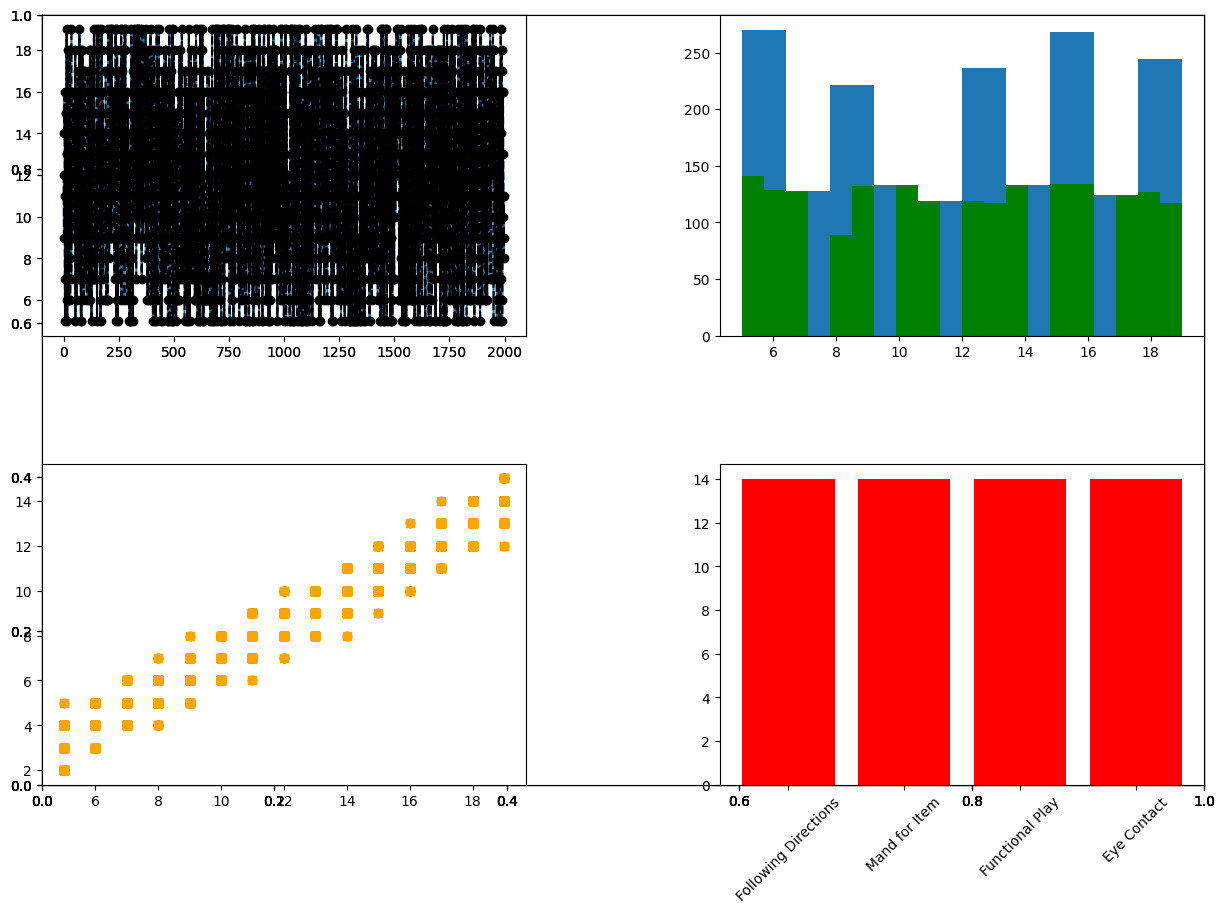

In [15]:
# copy all of the code above and paste it in the this cell (without the comments). 
# Use this cell to make modifications to the plots as instructed below. Only make the changes in this single cell. 
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(111)
ax2 = fig.add_subplot(111)
ax3 = fig.add_subplot(111)
ax4 = fig.add_subplot(111)
rohan_df = df[df['client_name'] == 'Rohan'].reset_index(drop=True)
ax1 = fig.add_subplot(221)
ax1.plot(rohan_df.index, rohan_df['trials'])
ax1 = fig.add_subplot(221)
ax1.plot(rohan_df.index, rohan_df['trials'])
ax2 = fig.add_subplot(222)
ax2.hist(rohan_df['trials'])
bob_df = df[df['client_name'] == 'Bob'].reset_index(drop=True)
ax3 = fig.add_subplot(223)
ax3.scatter(bob_df['trials'], bob_df['correct_responses'])
maddie_df = df[df['client_name'] == 'Maddie'].reset_index(drop=True)
ax4 = fig.add_subplot(224)
ax4.bar(maddie_df['target_behavior'], maddie_df['correct_responses'])
plt.subplots_adjust(hspace=0.0, wspace=0.0)

# Q17 Make the dimensions of the figure (15, 10)
fig.set_size_inches(15, 10)
# Q18 Make the bar plot red
ax4.bar(maddie_df['target_behavior'], maddie_df['correct_responses'], color='red')
# Q19 Make the line plot black with a dashed line and a circle marker
ax1.plot(rohan_df.index, rohan_df['trials'], color='black', linestyle='--', marker='o')
# Q20 Adjust the spacing between the subplots so they are further apart
plt.subplots_adjust(hspace=0.4, wspace=0.4)
# Q21 Make the scatterplot orange with a circle square marker
ax3.scatter(bob_df['trials'], bob_df['correct_responses'], color='orange', marker='s')
# Q22 Make the histogram plot green with 20 bins
ax2.hist(rohan_df['trials'], color='green', bins=20)
# Q23 Make the x labels for the bar plot at a 45 degree angle
ax4.tick_params(axis='x', rotation=45)

In [16]:
# Now let's work on a single plot. 
# Q24 Create a dataframe titled moana_df that only includes info from the client Moana. 
# Reset the index and drop the old index. Show the first 5 rows of the dataframe.
moana_df = df[df['client_name'] == 'Moana'].reset_index(drop=True)
moana_df.head()

,session_id,date,client_name,therapist,target_behavior,reinforcement_strategy,trials,prompt_level,session_duration,session_type,engagement_level,challenging_behavior_observed,therapist_notes,correct_responses
0,cf43e38b-40d4-4c4e-ab8e-dabe6260cf75,2025-01-01 07:00,Moana,Lily,Eye Contact,Break Time,5.0,Partial,90,In-Person,Low,No,Great session!,2
1,bf89a073-9867-41c2-926a-cc33280150e0,2025-01-01 08:00,Moana,Blaze,Eye Contact,Verbal Praise,16.0,Full,98,In-Person,Low,Yes,Some difficulty transitioning,8
2,cb360638-1955-40bb-820e-05e227c5ed03,2025-01-01 10:00,Moana,Blaze,Eye Contact,Token System,7.0,Full,35,Telehealth,Moderate,No,Needed multiple prompts,3
3,42b9a049-3187-437b-beaa-34a696e21d4c,2025-01-01 11:00,Moana,Emmet,Following Directions,Token System,6.0,Independent,104,Telehealth,Moderate,No,Needed multiple prompts,3
4,2e9d576c-7601-405a-a313-0bda28c1e7c4,2025-01-01 14:00,Moana,Uma,Mand for Item,Edible,15.0,Independent,97,In-Person,Low,Yes,Some difficulty transitioning,7


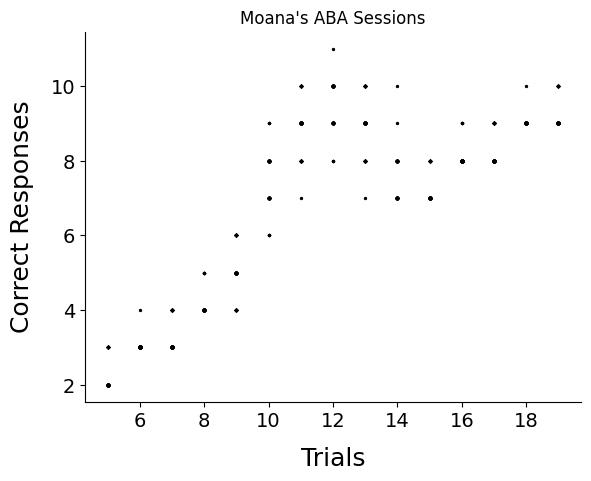

In [17]:
# Q25 Use the fig, ax = plt.subplots() function to create a new figure and subplot object. 
fig, ax = plt.subplots()
# Q26 create a scatterplot with the trials on the x axis and the correct_responses on the y axis. The size of the markers should be 2 and the color should be black. 
ax.scatter(moana_df['trials'], moana_df['correct_responses'], s=2, color='black')
# Q27 add a title to the plot called "Moana's ABA Sessions"
ax.set_title("Moana's ABA Sessions")
# Q28 add a x label to the plot called "Trials", give a font size of 18 and a labelpad of 12
ax.set_xlabel("Trials", fontsize=18, labelpad=12)
# Q29 add a y label to the plot called "Correct Responses" give a font size of 18 and a labelpad of 12
ax.set_ylabel("Correct Responses", fontsize=18, labelpad=12)
# Q30 Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Q31 Increase the font size of the tick labels on the x axis to 14
ax.tick_params(axis='x', labelsize=14)
# Q32 Increase the font size of the tick labels on the y axis to 14
ax.tick_params(axis='y', labelsize=14)
# Q33 Save the figure as a png file called "moana_aba_sessions.png"
fig.savefig("moana_aba_sessions.png")
# Q34 Use the plt.show() function to display the plot
plt.show()

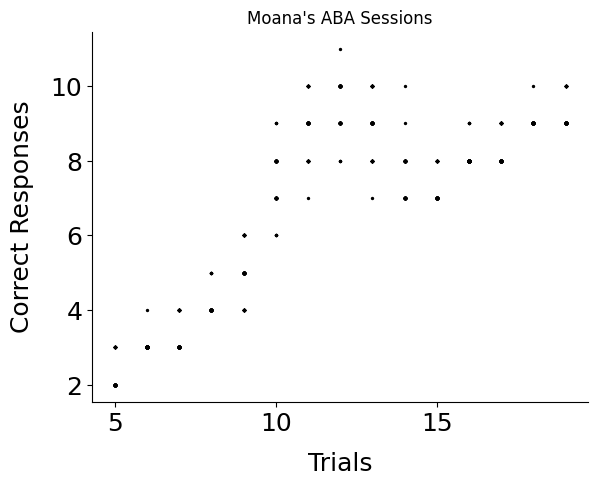

In [18]:
# Q35 Let's turn the above plot into a dynamic function. The function should be called plot_scatter. 
# The function should take the following arguments:
# - df: the dataframe to plot - REQUIRED
# - client_name: the name of the client to plot - REQUIRED
# - title: the title of the plot - REQUIRED
# - xlabel: the label of the x axis - REQUIRED
# - ylabel: the label of the y axis - REQUIRED
# - s: the size of the markers - OPTIONAL, DEFAULT IS 2
# - color: the color of the markers - OPTIONAL, DEFAULT IS BLACK
# - fontsize: the font size of the tick labels - OPTIONAL, DEFAULT IS 18
# - labelpad: the padding of the tick labels - OPTIONAL, DEFAULT IS 12
def plot_scatter(df, client_name, title, xlabel, ylabel, s=2, color='black', fontsize=18, labelpad=12):
    client_df = df[df['client_name'] == client_name].reset_index(drop=True)
    
    fig, ax = plt.subplots()
    ax.scatter(client_df['trials'], client_df['correct_responses'], s=s, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel, fontsize=fontsize, labelpad=labelpad)
    ax.set_ylabel(ylabel, fontsize=fontsize, labelpad=labelpad)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    plt.show()
    
# Q36 Call the function with the df dataframe, the client name moana, the title "Moana's ABA Sessions", 
# the xlabel "Trials", the ylabel "Correct Responses", 
# the size of the markers 2, the color black, the font size 18, and the label pad 12
plot_scatter(df, 'Moana', "Moana's ABA Sessions", 'Trials', 'Correct Responses', s=2, color='black', fontsize=18, labelpad=12)

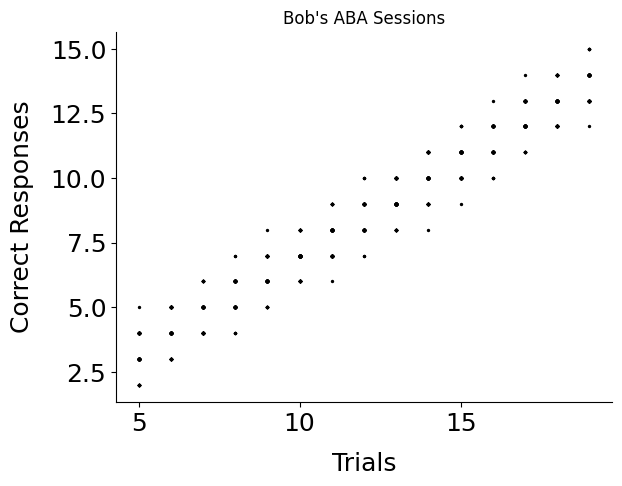

In [19]:
# Q37 Call the function with the df dataframe, the client name Bob, the title "Bob's ABA Sessions", 
# the xlabel "Trials", the ylabel "Correct Responses", the size of the markers 2, 
# the color black, the font size 18, and the label pad 12
plot_scatter(df, 'Bob', "Bob's ABA Sessions", 'Trials', 'Correct Responses', s=2, color='black', fontsize=18, labelpad=12)

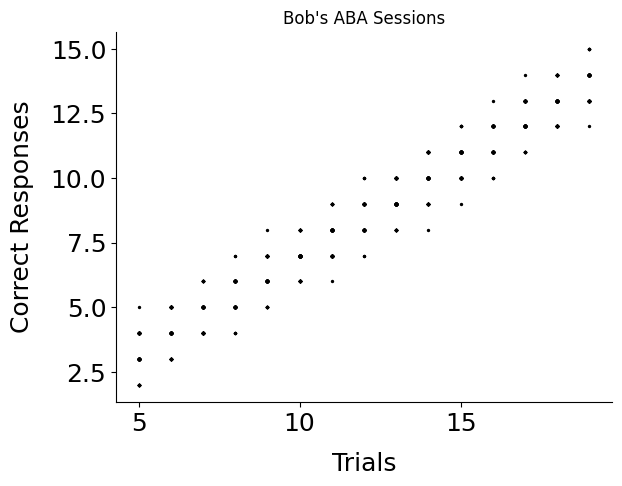

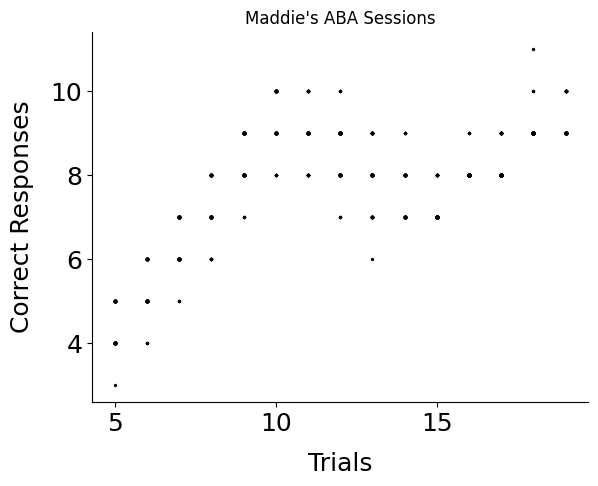

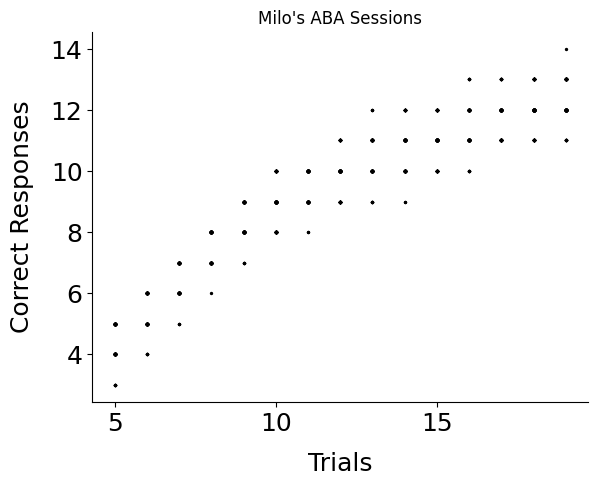

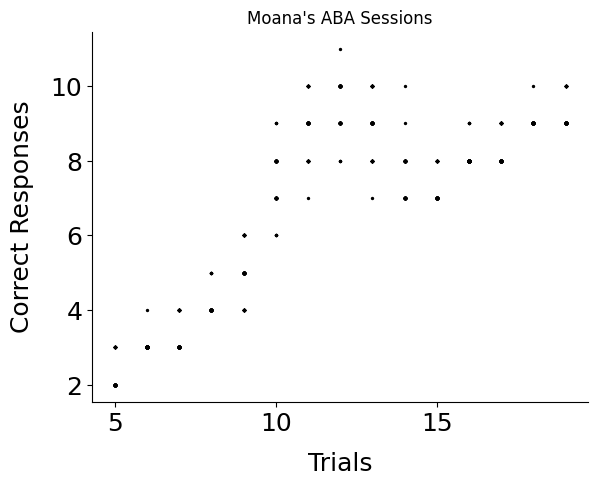

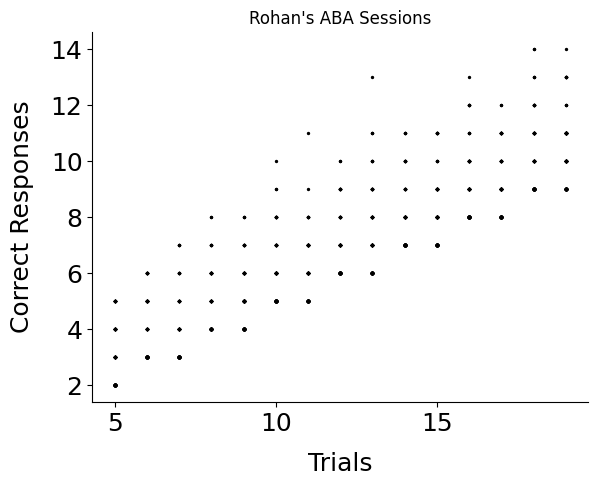

In [20]:
# Q38 Iterate over a grouped dataframe and plot each client's data
for client_name, client_df in df.groupby('client_name'):
    plot_scatter(df, client_name, f"{client_name}'s ABA Sessions", 'Trials', 'Correct Responses')

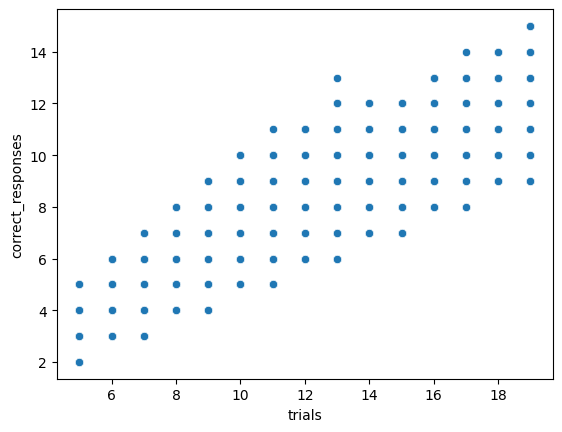

In [21]:
# Now we will use seaborn to create different plots. We will still use matplotlib to manage some aspects of the plot. 
# Q39 Create a scatterplot of the trials on the x axis and the correct_responses on the y axis. 
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='trials', y='correct_responses', ax=ax)
plt.show()

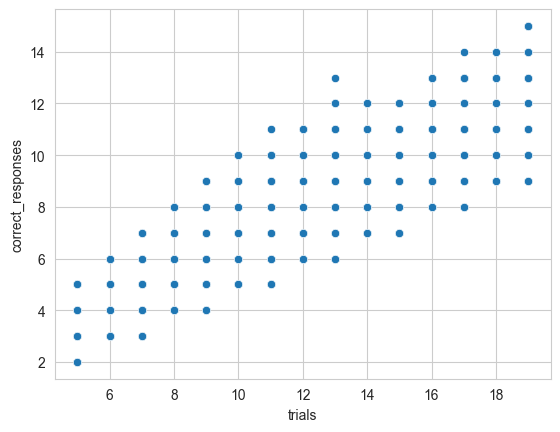

In [22]:
# Q40 Update the style to be whitegrid and make the plot a scatterplot 
# of the trials on the x axis and the correct_responses on the y axis. 
sns.set_style('whitegrid')
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='trials', y='correct_responses', ax=ax)
plt.show()

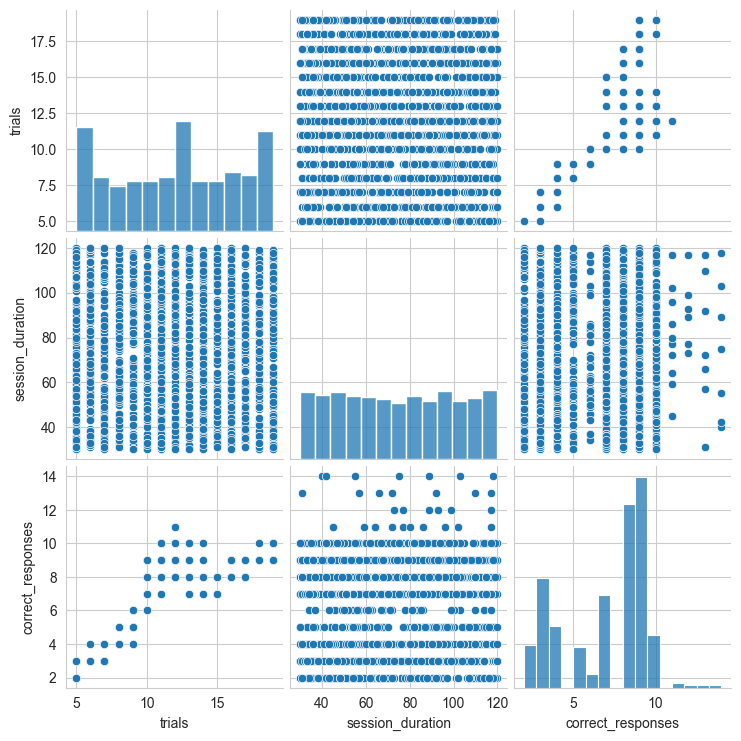

In [23]:
# Q41 Use the moana_df dataframe to create a pairplot of the trials on the x axis and the correct_responses on the y axis. 
sns.pairplot(moana_df)
plt.show()

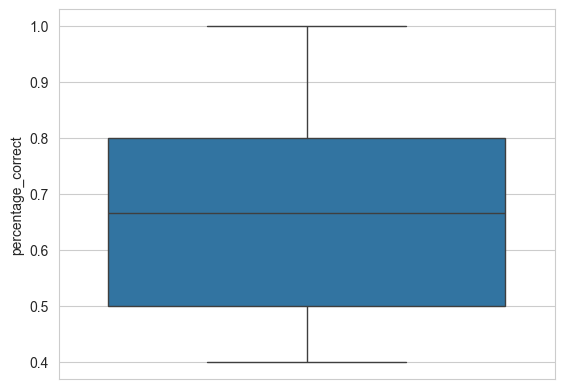

In [24]:
# Q42 Create a column called percentage correct that is the correct_responses divided by the trials. 
df['percentage_correct'] = df['correct_responses'] / df['trials']
# Q43 Create a boxplot of the percentage correct column. 
fig, ax = plt.subplots()
sns.boxplot(data=df, y='percentage_correct', ax=ax)
plt.show()

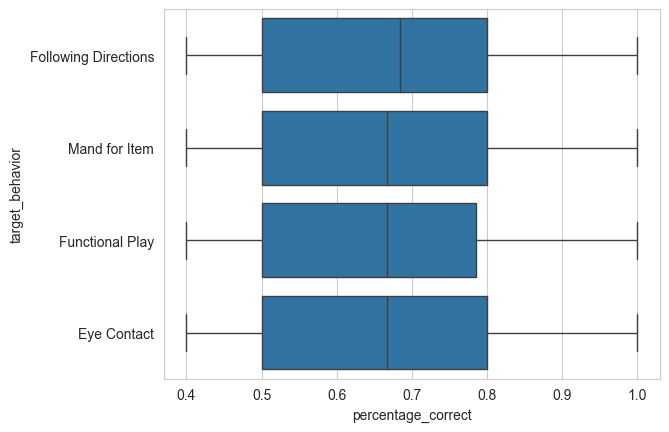

In [25]:
# Q44 Create a boxplot using seaborn of the percentage correct column, set the y axis to be the target behavior . 
fig, ax = plt.subplots()
sns.boxplot(data=df, x='percentage_correct', y='target_behavior', ax=ax)
plt.show()

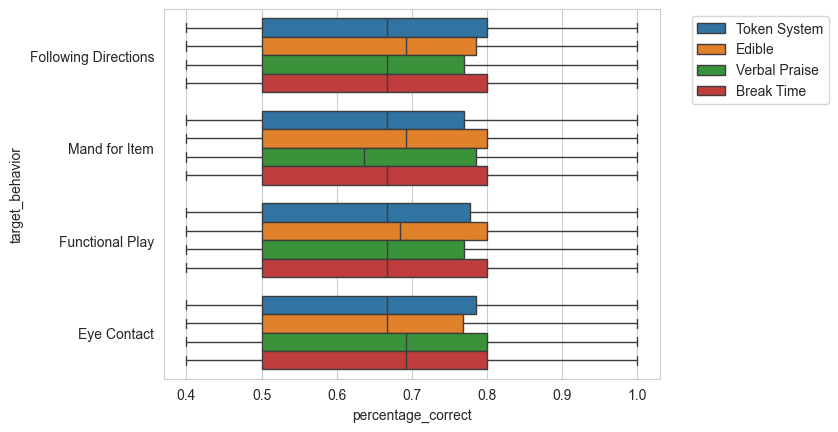

In [26]:
# Q45 Create a boxplot using seaborn of the percentage correct column, 
# set the y axis to be the target behavior and the hue to be the reinforcement strategy. 
# Make sure the legend falls outside the main plot
fig, ax = plt.subplots()
sns.boxplot(data=df, x='percentage_correct', y='target_behavior', hue='reinforcement_strategy', ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

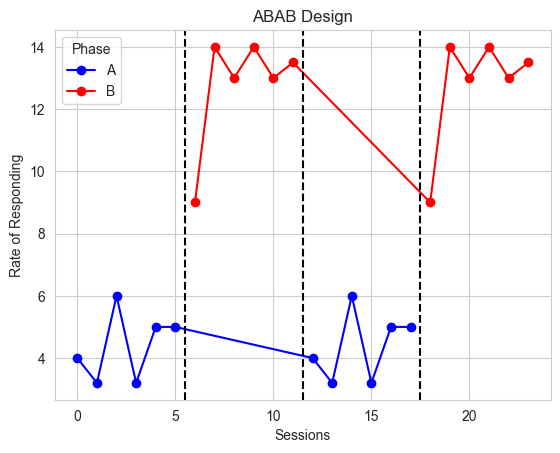

In [27]:
# Q46 Create an ABAB plot using the data provided below. 
# Include phase change lines and make sure the markers are different colors for the unique phases. 

# Code to create DataFrame for you
data = {
    "Sessions": ["A", "A", "A", "A", "A", "A", "B", "B", "B", "B", "B", "B", 
                 "A", "A", "A", "A", "A", "A", "B", "B", "B", "B", "B", "B"],
    "rate_of_responding": [4, 3.2, 6, 3.2, 5, 5, 9, 14, 13, 14, 13, 13.5,
                            4, 3.2, 6, 3.2, 5, 5, 9, 14, 13, 14, 13, 13.5]
}

df = pd.DataFrame(data)

# START YOUR CODE HERE
fig, ax = plt.subplots()

colors = {'A': 'blue', 'B': 'red'}

for phase, group in df.groupby('Sessions', sort=False):
    ax.plot(group.index, group['rate_of_responding'], 
            color=colors[phase], marker='o', label=phase)

phase_changes = df[df['Sessions'] != df['Sessions'].shift()].index[1:]
for change in phase_changes:
    ax.axvline(x=change - 0.5, color='black', linestyle='--')

ax.set_xlabel('Sessions')
ax.set_ylabel('Rate of Responding')
ax.set_title('ABAB Design')
ax.legend(title='Phase')
plt.show()

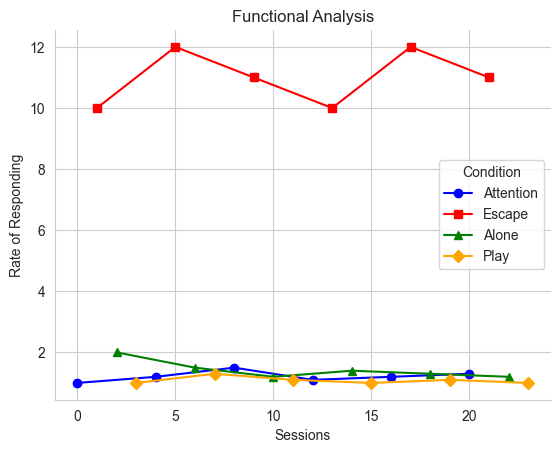

In [28]:
# Q46 - Create a functional analysis plot using the data provided below. 

# Code to Create DataFrame for Multielement Design
data = {
    "Sessions": ["Attention", "Escape", "Alone", "Play", "Attention", "Escape", "Alone", "Play", "Attention", "Escape", "Alone", "Play",
                 "Attention", "Escape", "Alone", "Play", "Attention", "Escape", "Alone", "Play", "Attention", "Escape", "Alone", "Play"],
    "rate_of_responding": [1, 10, 2, 1, 1.2, 12, 1.5, 1.3, 1.5, 11, 1.2, 1.1,
                            1.1, 10, 1.4, 1, 1.2, 12, 1.3, 1.1, 1.3, 11, 1.2, 1]
}

df = pd.DataFrame(data)

# START YOUR CODE HERE
fig, ax = plt.subplots()

colors = {'Attention': 'blue', 'Escape': 'red', 'Alone': 'green', 'Play': 'orange'}
markers = {'Attention': 'o', 'Escape': 's', 'Alone': '^', 'Play': 'D'}

for condition, group in df.groupby('Sessions', sort=False):
    ax.plot(group.index, group['rate_of_responding'],
            color=colors[condition], marker=markers[condition], label=condition)

ax.set_xlabel('Sessions')
ax.set_ylabel('Rate of Responding')
ax.set_title('Functional Analysis')
ax.legend(title='Condition')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [32]:
# Q47 Go to one of the graph gallery pages from the reading guide. 
# Create a unique plot using the data from this notebook
import pandas as pd
import numpy as np
import random
import uuid

# Set the seed for reproducibility
np.random.seed(101214)

# Generate fake ABA session data
num_samples = 10_000
clients = ["Bob", "Rohan", "Milo", "Moana", "Maddie"]

data = {
    "session_id": [uuid.uuid4() for _ in range(num_samples)],
    "date": pd.date_range(start="2025-01-01", periods=num_samples, freq="h").strftime("%Y-%m-%d %H:%M"),
    "client_name": [str(np.random.choice(clients)) for _ in range(num_samples)],
    "therapist": [str(np.random.choice(["Emmet", "Blaze", "Uma", "Lily"])) for _ in range(num_samples)],
    "target_behavior": [str(np.random.choice(["Mand for Item", "Eye Contact", "Functional Play", "Following Directions"])) for _ in range(num_samples)],
    "reinforcement_strategy": [str(np.random.choice(["Token System", "Edible", "Verbal Praise", "Break Time"])) for _ in range(num_samples)],
    "trials": np.where(np.random.rand(num_samples) < 0.05, np.nan, np.random.randint(5, 20, size=num_samples)),
    "prompt_level": [str(np.random.choice(["Full", "Partial", "Independent"])) for _ in range(num_samples)],
    "session_duration": np.random.randint(30, 121, size=num_samples),
    "session_type": [str(np.random.choice(["In-Person", "Telehealth"])) for _ in range(num_samples)],
    "engagement_level": [np.random.choice(["High", "Moderate", "Low"]) for _ in range(num_samples)],
    "challenging_behavior_observed": [str(np.random.choice(["Yes", "No"], p=[0.3, 0.7])) for _ in range(num_samples)],
    "therapist_notes": [
        np.random.choice(["Client was focused", "Needed multiple prompts", "Great session!", "Some difficulty transitioning"])
        for _ in range(num_samples)
    ]
}

df = pd.DataFrame(data)

# Apply correlation-based generation for 'correct_responses' with 50%-100% range
correct_responses = []

for index, row in df.iterrows():
    trials = row['trials']
    client = row['client_name']

    if pd.isna(trials):
        # If trials is NaN, set a random value for correct_responses
        correct_responses.append(np.random.randint(3, 15))
        continue
    # Generate correct responses based on client type with 50%-100% of trials
    if client == "Bob":
        # 0.75 positive correlation
        mean_correct = np.clip(0.75 * trials, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    elif client == "Rohan":
        # 0.3 positive correlation
        mean_correct = np.clip(0.3 * trials, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 2), 0.5 * trials, trials)))
    elif client == "Milo":
        # Asymptotic relationship
        mean_correct = np.clip(15 * (1 - np.exp(-trials / 10)), 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    elif client == "Moana":
        # Inverted U relationship
        mean_correct = np.clip(-0.5 * (trials - 12) ** 2 + 10, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    elif client == "Maddie":
        # -0.5 negative correlation
        mean_correct = np.clip(15 - 0.5 * trials, 0.5 * trials, trials)
        correct_responses.append(int(np.clip(np.random.normal(mean_correct, 0.5), 0.5 * trials, trials)))
    else:
        # Default case if something goes wrong
        correct_responses.append(int(np.clip(np.random.uniform(0.5, 1.0) * trials, 0.5 * trials, trials)))

# Assign the generated 'correct_responses' to the DataFrame
df['correct_responses'] = correct_responses

df.head()

,session_id,date,client_name,therapist,target_behavior,reinforcement_strategy,trials,prompt_level,session_duration,session_type,engagement_level,challenging_behavior_observed,therapist_notes,correct_responses
0,cff23b7c-d9b2-40f6-aeb2-b2a8f881d3b2,2025-01-01 00:00,Maddie,Uma,Following Directions,Token System,7.0,Independent,51,Telehealth,Low,Yes,Client was focused,7
1,8a3ef43c-afd2-4ba6-8ffb-9d76e74b3989,2025-01-01 01:00,Maddie,Blaze,Mand for Item,Edible,16.0,Full,86,Telehealth,High,No,Some difficulty transitioning,8
2,4c8c982e-3a3f-4d86-b732-c023a33fb557,2025-01-01 02:00,Maddie,Lily,Functional Play,Token System,19.0,Independent,93,Telehealth,Moderate,Yes,Great session!,9
3,277ea360-aa09-4daa-abd1-ad780f3a0502,2025-01-01 03:00,Rohan,Uma,Mand for Item,Token System,12.0,Partial,99,In-Person,Moderate,Yes,Client was focused,6
4,9bd1138d-2082-4dd3-931e-96b226937316,2025-01-01 04:00,Rohan,Emmet,Mand for Item,Edible,9.0,Partial,111,In-Person,High,Yes,Some difficulty transitioning,5


KeyError: 'percentage_correct'

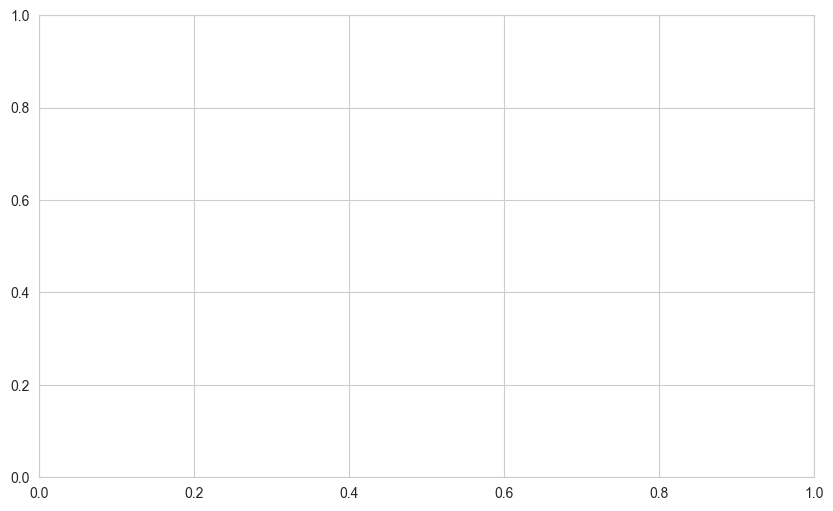

In [34]:
from scipy.stats import gaussian_kde
import numpy as np

clients = df['client_name'].unique()
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 6))

for i, client in enumerate(clients):
    values = df[df['client_name'] == client]['percentage_correct'].dropna()
    kde = gaussian_kde(values)
    x_range = np.linspace(values.min(), values.max(), 200)
    y = kde(x_range)
    y = y / y.max() * 0.8

    ax.fill_between(x_range, i + y, i, alpha=0.6, color=colors[i % len(colors)])
    ax.plot(x_range, i + y, color=colors[i % len(colors)])

ax.set_yticks(range(len(clients)))
ax.set_yticklabels(clients)
ax.set_xlabel('Percentage Correct', fontsize=14)
ax.set_title('Ridgeline Plot of Percentage Correct by Client', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()